In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.chdir('/content/drive/MyDrive/NLP/Translation')
!ls

'arabic dataset'      get-pip.py.1		  'Translation v1.ipynb'
'chinese dataset'    'italian dataset'		  'Translation v2.ipynb'
 Datasets.ipynb       mbert_confusion_matrix.png  'Translation v3.ipynb'
'Datasets v2.ipynb'   mbert_final		  'Translation v4.ipynb'
 figures	      merged_datasets		  'Translation v5.ipynb'
 final_models	      results			  'Translation v6.ipynb'
 final_models_v2      sentiment_gpt3_train.jsonl   xlmr_best_model
'french dataset'      tmp_trainer		   xlmr_confusion_matrix.png
 get-pip.py	      translation_comparison.csv


In [54]:
import pandas as pd

DATA_PATH = "merged_datasets/merged_balanced_translated_google_clean.csv"

df = pd.read_csv(DATA_PATH)
print("✅ Veri yüklendi:", df.shape)
print("\n📂 Sütunlar:", df.columns.tolist())
df.head(3)

✅ Veri yüklendi: (11997, 4)

📂 Sütunlar: ['text', 'sentiment', 'language', 'translated_text']


,text,sentiment,language,translated_text
0,بطلنا نحكم على الناس من شكلهم و لبسهم و تمن خر...,NEG,ar,"We stopped judging people by their looks, thei..."
1,vérifier la quantité à la livraison jai acheté...,NEG,fr,check the quantity on delivery I bought these ...
2,برومو حلقة بائع الليمون ثاني حلقات الأنيميشن م...,NEG,ar,"Promo for the Lemon Seller episode, the second..."


In [55]:
df = df.dropna(subset=["translated_text", "sentiment"]).copy()
df["translated_text"] = df["translated_text"].astype(str)

label_map = {"NEG": 0, "NEUTRAL": 1, "POS": 2}
df["label"] = df["sentiment"].map(label_map).astype(int)

before = len(df)
df = df.drop_duplicates(subset=["translated_text"]).reset_index(drop=True)
print(f"🧹 Duplicate temizliği: {before} → {len(df)}")

print("\n🎯 Sınıf dağılımı:")
print(df["sentiment"].value_counts())

print("\n🌍 Dil dağılımı:")
print(df["language"].value_counts())

🧹 Duplicate temizliği: 11997 → 11937

🎯 Sınıf dağılımı:
sentiment
NEG        4848
POS        3825
NEUTRAL    3264
Name: count, dtype: int64

🌍 Dil dağılımı:
language
fr    3000
zh    2999
ar    2977
it    2961
Name: count, dtype: int64


In [56]:
from sklearn.model_selection import train_test_split

SEED = 42

strat_key = df["language"].astype(str) + "_" + df["label"].astype(str)

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=strat_key,
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"✅ Train set: {train_df.shape}")
print(f"✅ Test  set: {test_df.shape}")

print("\n🎯 Test sınıf dağılımı:")
print(test_df["sentiment"].value_counts())

print("\n🌍 Test dil dağılımı:")
print(test_df["language"].value_counts())

overlap = set(train_df["translated_text"]).intersection(set(test_df["translated_text"]))
print(f"\n⚠️ Train-Test ortak metin: {len(overlap)} (0 olmalı)")

✅ Train set: (9549, 5)
✅ Test  set: (2388, 5)

🎯 Test sınıf dağılımı:
sentiment
NEG        969
POS        766
NEUTRAL    653
Name: count, dtype: int64

🌍 Test dil dağılımı:
language
zh    600
fr    600
ar    595
it    593
Name: count, dtype: int64

⚠️ Train-Test ortak metin: 0 (0 olmalı)


In [57]:
TEST_SAVE_PATH  = "/content/drive/MyDrive/NLP/Translation/merged_datasets/holdout_test_google.csv"
TRAIN_SAVE_PATH = "/content/drive/MyDrive/NLP/Translation/merged_datasets/holdout_train_google.csv"

test_df.to_csv(TEST_SAVE_PATH, index=False, encoding="utf-8")
train_df.to_csv(TRAIN_SAVE_PATH, index=False, encoding="utf-8")

print(f"💾 Test  kaydedildi: {TEST_SAVE_PATH}")
print(f"💾 Train kaydedildi: {TRAIN_SAVE_PATH}")

💾 Test  kaydedildi: /content/drive/MyDrive/NLP/Translation/merged_datasets/holdout_test_google.csv
💾 Train kaydedildi: /content/drive/MyDrive/NLP/Translation/merged_datasets/holdout_train_google.csv


In [58]:
import torch
from transformers import AutoTokenizer

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Tokenizer yüklendi: {MODEL_NAME}")
print(f"💻 Device: {device}")
if device == "cuda":
    print(f"🖥️ GPU: {torch.cuda.get_device_name(0)}")

✅ Tokenizer yüklendi: cardiffnlp/twitter-roberta-base-sentiment
💻 Device: cuda
🖥️ GPU: NVIDIA A100-SXM4-40GB


In [3]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)

def macro_specificity(y_true, y_pred, num_labels=3):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_labels)))
    specs = []
    total = cm.sum()
    for i in range(num_labels):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        specs.append(spec)
    return float(np.mean(specs))

def compute_metrics_fn(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "precision_w": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall_w":    recall_score(labels, preds, average="weighted", zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "specificity": macro_specificity(labels, preds, num_labels=3),
    }

print("✅ Metrik fonksiyonları hazır.")

✅ Metrik fonksiyonları hazır.


In [61]:
from sklearn.model_selection import StratifiedKFold
from datasets import Dataset

def tokenize_batch(batch):
    return tokenizer(
        batch["translated_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"✅ 5-Fold CV hazır. Train boyutu: {len(train_df)}")
print(f"   (Her fold: ~{len(train_df)*4//5} train / ~{len(train_df)//5} val)")

✅ 5-Fold CV hazır. Train boyutu: 9549
   (Her fold: ~7639 train / ~1909 val)


In [63]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import torch, gc

cv_results = []

for fold, (tr_idx, va_idx) in enumerate(
    skf.split(train_df["translated_text"], train_df["label"]), start=1
):
    print(f"\n📘 Fold {fold}/5 başlıyor...")

    tr_sub = train_df.iloc[tr_idx][["translated_text", "label"]]
    va_sub = train_df.iloc[va_idx][["translated_text", "label"]]

    tr_ds = Dataset.from_pandas(tr_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )
    va_ds = Dataset.from_pandas(va_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

    args = TrainingArguments(
        output_dir=f"/content/roberta_cv/fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        save_total_limit=1,
        bf16=True,
        dataloader_num_workers=2,
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        compute_metrics=compute_metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"📊 Fold {fold} sonuçları: {metrics}")
    cv_results.append(metrics)

    del model, trainer, tr_ds, va_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ 5-Fold CV tamamlandı.")


📘 Fold 1/5 başlıyor...


Map:   0%|          | 0/7639 [00:00<?, ? examples/s]

Map:   0%|          | 0/1910 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

📊 Fold 5 sonuçları: {'eval_loss': 0.7869758605957031, 'eval_accuracy': 0.7108433734939759, 'eval_precision_w': 0.706679936405816, 'eval_recall_w': 0.7108433734939759, 'eval_f1_weighted': 0.7084489003911757, 'eval_specificity': 0.8545327065131424, 'eval_runtime': 1.123, 'eval_samples_per_second': 1699.95, 'eval_steps_per_second': 53.43, 'epoch': 3.0}

✅ 5-Fold CV tamamlandı.


In [64]:
import pandas as pd

cv_df = pd.DataFrame(cv_results)
cv_df.index = [f"Fold {i+1}" for i in range(len(cv_df))]

metric_cols = ["eval_accuracy", "eval_precision_w", "eval_recall_w", "eval_f1_weighted", "eval_specificity"]
summary = cv_df[metric_cols].copy()
summary.loc["Mean"] = summary.mean()
summary.loc["Std"]  = cv_df[metric_cols].std()

summary.columns = ["Accuracy", "Precision", "Recall", "F1", "Specificity"]
print("📊 5-Fold CV Özet (Train set üzerinde):\n")
print(summary.round(4))

📊 5-Fold CV Özet (Train set üzerinde):

        Accuracy  Precision  Recall      F1  Specificity
Fold 1    0.7147     0.7097  0.7147  0.7117       0.8565
Fold 2    0.7047     0.7019  0.7047  0.7032       0.8522
Fold 3    0.7084     0.7052  0.7084  0.7063       0.8531
Fold 4    0.7016     0.6968  0.7016  0.6987       0.8498
Fold 5    0.7108     0.7067  0.7108  0.7084       0.8545
Mean      0.7080     0.7041  0.7080  0.7057       0.8532
Std       0.0051     0.0049  0.0051  0.0050       0.0025


In [65]:
import pandas as pd

fold_table = pd.DataFrame({
    "Model": ["RoBERTa"],
    "Fold 1": [cv_results[0]["eval_f1_weighted"]],
    "Fold 2": [cv_results[1]["eval_f1_weighted"]],
    "Fold 3": [cv_results[2]["eval_f1_weighted"]],
    "Fold 4": [cv_results[3]["eval_f1_weighted"]],
    "Fold 5": [cv_results[4]["eval_f1_weighted"]],
})
fold_table["Average"] = fold_table[["Fold 1","Fold 2","Fold 3","Fold 4","Fold 5"]].mean(axis=1)

print(fold_table.round(4).to_string(index=False))

  Model  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Average
RoBERTa  0.7117  0.7032  0.7063  0.6987  0.7084   0.7057


In [67]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset
import torch, gc

full_train_ds = Dataset.from_pandas(
    train_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

final_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

final_args = TrainingArguments(
    output_dir="/content/roberta_final_google",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    bf16=True,
    dataloader_num_workers=2,
    seed=SEED,
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=full_train_ds,
)

final_trainer.train()
print("\n✅ Final RoBERTa modeli eğitildi.")

Map:   0%|          | 0/9549 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
597,0.748457
1194,0.590138
1791,0.441627



✅ Final RoBERTa modeli eğitildi.


In [68]:
from datasets import Dataset
import numpy as np

test_ds = Dataset.from_pandas(
    test_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

pred_output = final_trainer.predict(test_ds)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=-1)

print(f"✅ Tahmin tamamlandı. Test boyutu: {len(y_true)}")

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

✅ Tahmin tamamlandı. Test boyutu: 2388


In [69]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import pandas as pd
import numpy as np

label_names = ["NEG", "NEUTRAL", "POS"]

cm = confusion_matrix(y_true, y_pred)

def per_class_specificity(cm):
    total = cm.sum()
    specs = []
    for i in range(len(cm)):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        specs.append(TN / (TN + FP) if (TN + FP) > 0 else 0.0)
    return specs

per_class = pd.DataFrame({
    "Accuracy":    [np.nan]*3,
    "Precision":   precision_score(y_true, y_pred, average=None, zero_division=0),
    "Recall":      recall_score(y_true, y_pred, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true, y_pred, average=None, zero_division=0),
    "Specificity": per_class_specificity(cm),
}, index=label_names)

overall = pd.Series({
    "Accuracy":    accuracy_score(y_true, y_pred),
    "Precision":   precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "Specificity": np.mean(per_class_specificity(cm)),
}, name="Overall (weighted)")

report = pd.concat([per_class, overall.to_frame().T])
print("📊 Classification Report — RoBERTa (Google Translate)\n")
print(report.round(4).to_string())

📊 Classification Report — RoBERTa (Google Translate)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.7651  0.7730    0.7690       0.8379
NEUTRAL                  NaN     0.5462  0.4977    0.5208       0.8444
POS                      NaN     0.7494  0.7963    0.7722       0.8742
Overall (weighted)    0.7052     0.7002  0.7052    0.7021       0.8522


In [72]:
languages = ["ar", "zh", "fr", "it"]
lang_names = {"ar": "Arabic", "zh": "Chinese", "fr": "French", "it": "Italian"}

test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["pred"] = y_pred
test_df_reset["true"] = y_true

lang_results = {}
for lang in languages:
    sub = test_df_reset[test_df_reset["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values

    cm_lang = confusion_matrix(yt, yp, labels=[0, 1, 2])
    spec_lang = np.mean(per_class_specificity(cm_lang))

    lang_results[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_lang,
    }

lang_report = pd.DataFrame(lang_results).round(4)
print("📊 Dil Bazlı Classification Report — RoBERTa (Google Translate)\n")
print(lang_report.to_string())

📊 Dil Bazlı Classification Report — RoBERTa (Google Translate)

             Arabic  Chinese  French  Italian
Accuracy     0.6622   0.7283  0.7917   0.6374
Precision    0.6606   0.7218  0.7874   0.6406
Recall       0.6622   0.7283  0.7917   0.6374
F1-Score     0.6609   0.7245  0.7893   0.6368
Specificity  0.8219   0.8633  0.8967   0.8143


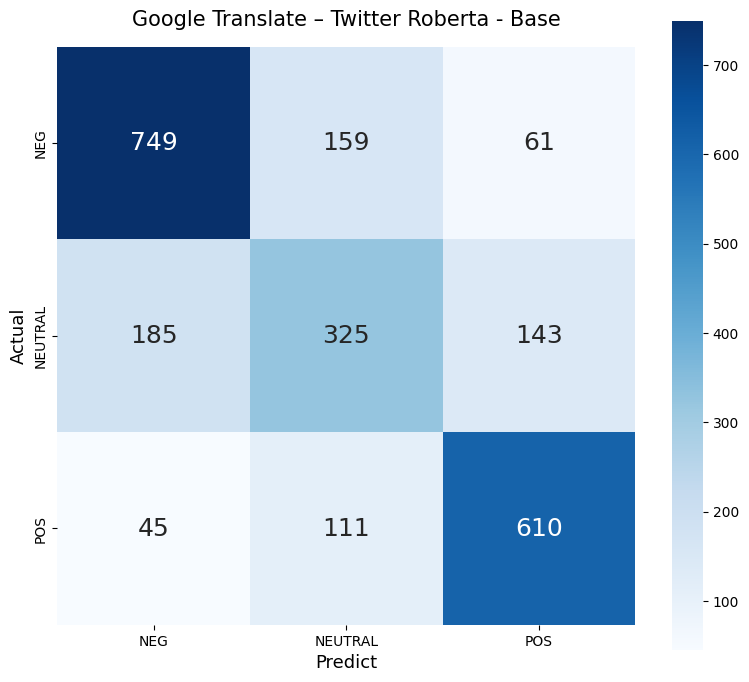


💾 Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_google_roberta.png


In [73]:
import os

save_dir = "/content/drive/MyDrive/NLP/Translation/figures"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "cm_google_roberta.png")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    cbar=True,
    square=True,
    annot_kws={"size": 18},
    ax=ax,
)
ax.set_xlabel("Predict", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
ax.set_title("Google Translate – Twitter Roberta - Base", fontsize=15, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n💾 Kaydedildi: {save_path}")

In [74]:
!pip -q install emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [78]:
from transformers import AutoTokenizer

MODEL_NAME = "vinai/bertweet-base"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, normalization=True)

print(f"✅ Tokenizer yüklendi: {MODEL_NAME}")
print(f"Tokenizer class: {type(tokenizer).__name__}")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer yüklendi: vinai/bertweet-base
Tokenizer class: BertweetTokenizer


In [80]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset
import torch, gc

cv_results_bertweet = []

for fold, (tr_idx, va_idx) in enumerate(
    skf.split(train_df["translated_text"], train_df["label"]), start=1
):
    print(f"\n📘 Fold {fold}/5 başlıyor...")

    tr_sub = train_df.iloc[tr_idx][["translated_text", "label"]]
    va_sub = train_df.iloc[va_idx][["translated_text", "label"]]

    tr_ds = Dataset.from_pandas(tr_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )
    va_ds = Dataset.from_pandas(va_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

    args = TrainingArguments(
        output_dir=f"/content/bertweet_cv/fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        save_total_limit=1,
        bf16=True,
        dataloader_num_workers=2,
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        compute_metrics=compute_metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"📊 Fold {fold} sonuçları: {metrics}")
    cv_results_bertweet.append(metrics)

    del model, trainer, tr_ds, va_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ BERTweet 5-Fold CV tamamlandı.")


📘 Fold 1/5 başlıyor...


Map:   0%|          | 0/7639 [00:00<?, ? examples/s]

Map:   0%|          | 0/1910 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

📊 Fold 5 sonuçları: {'eval_loss': 0.7035927176475525, 'eval_accuracy': 0.7003666841278157, 'eval_precision_w': 0.7063849875651043, 'eval_recall_w': 0.7003666841278157, 'eval_f1_weighted': 0.7027065055271946, 'eval_specificity': 0.8504039946971956, 'eval_runtime': 1.1422, 'eval_samples_per_second': 1671.31, 'eval_steps_per_second': 52.529, 'epoch': 3.0}

✅ BERTweet 5-Fold CV tamamlandı.


In [81]:
import pandas as pd

cv_df_bw = pd.DataFrame(cv_results_bertweet)
cv_df_bw.index = [f"Fold {i+1}" for i in range(len(cv_df_bw))]

metric_cols = ["eval_accuracy", "eval_precision_w", "eval_recall_w", "eval_f1_weighted", "eval_specificity"]
summary_bw = cv_df_bw[metric_cols].copy()
summary_bw.loc["Mean"] = summary_bw.mean()
summary_bw.loc["Std"]  = cv_df_bw[metric_cols].std()

summary_bw.columns = ["Accuracy", "Precision", "Recall", "F1", "Specificity"]
print("📊 BERTweet 5-Fold CV Özet:\n")
print(summary_bw.round(4))

📊 BERTweet 5-Fold CV Özet:

        Accuracy  Precision  Recall      F1  Specificity
Fold 1    0.7115     0.7028  0.7115  0.7054       0.8549
Fold 2    0.7173     0.7136  0.7173  0.7152       0.8581
Fold 3    0.7031     0.7072  0.7031  0.7050       0.8526
Fold 4    0.7021     0.7068  0.7021  0.7039       0.8512
Fold 5    0.7004     0.7064  0.7004  0.7027       0.8504
Mean      0.7069     0.7074  0.7069  0.7064       0.8534
Std       0.0072     0.0039  0.0072  0.0050       0.0031


In [83]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset
import torch, gc

full_train_ds = Dataset.from_pandas(
    train_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

final_model_bw = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

final_args_bw = TrainingArguments(
    output_dir="/content/bertweet_final_google",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    bf16=True,
    dataloader_num_workers=2,
    seed=SEED,
)

final_trainer_bw = Trainer(
    model=final_model_bw,
    args=final_args_bw,
    train_dataset=full_train_ds,
)

final_trainer_bw.train()
print("\n✅ Final BERTweet modeli eğitildi.")

Map:   0%|          | 0/9549 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Step,Training Loss
597,0.830052
1194,0.615035
1791,0.486223



✅ Final BERTweet modeli eğitildi.


In [84]:
from datasets import Dataset
import numpy as np

test_ds = Dataset.from_pandas(
    test_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

pred_output_bw = final_trainer_bw.predict(test_ds)
y_true_bw = pred_output_bw.label_ids
y_pred_bw = np.argmax(pred_output_bw.predictions, axis=-1)

print(f"✅ BERTweet tahmin tamamlandı. Test boyutu: {len(y_true_bw)}")

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

✅ BERTweet tahmin tamamlandı. Test boyutu: 2388


In [85]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
import pandas as pd
import numpy as np

cm_bw = confusion_matrix(y_true_bw, y_pred_bw)

per_class_bw = pd.DataFrame({
    "Accuracy":    [np.nan]*3,
    "Precision":   precision_score(y_true_bw, y_pred_bw, average=None, zero_division=0),
    "Recall":      recall_score(y_true_bw, y_pred_bw, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true_bw, y_pred_bw, average=None, zero_division=0),
    "Specificity": per_class_specificity(cm_bw),
}, index=label_names)

overall_bw = pd.Series({
    "Accuracy":    accuracy_score(y_true_bw, y_pred_bw),
    "Precision":   precision_score(y_true_bw, y_pred_bw, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true_bw, y_pred_bw, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true_bw, y_pred_bw, average="weighted", zero_division=0),
    "Specificity": np.mean(per_class_specificity(cm_bw)),
}, name="Overall (weighted)")

report_bw = pd.concat([per_class_bw, overall_bw.to_frame().T])
print("📊 Classification Report — BERTweet (Google Translate)\n")
print(report_bw.round(4).to_string())

📊 Classification Report — BERTweet (Google Translate)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.7562  0.7554    0.7558       0.8337
NEUTRAL                  NaN     0.5198  0.4824    0.5004       0.8323
POS                      NaN     0.7297  0.7755    0.7519       0.8644
Overall (weighted)    0.6872     0.6831  0.6872    0.6847       0.8434


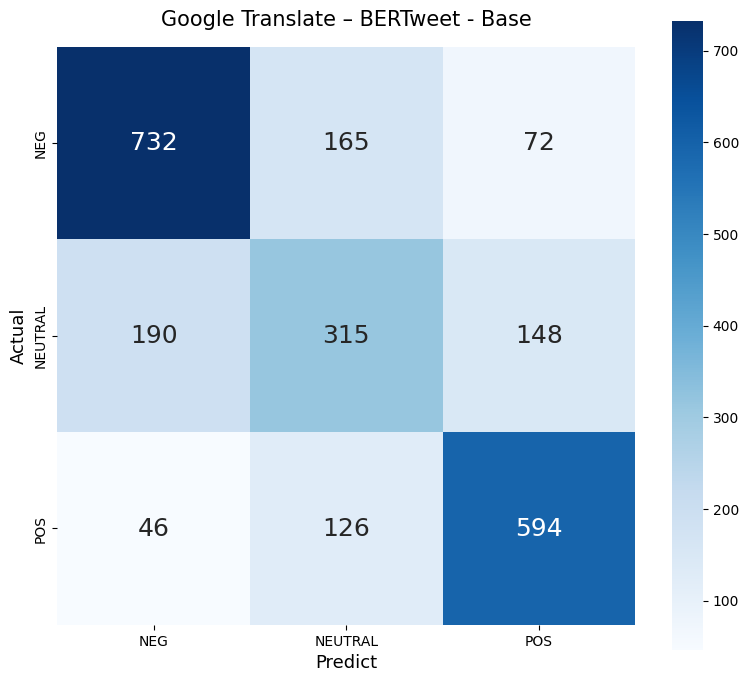


💾 Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_google_bertweet.png

📦 Ham Confusion Matrix:
         NEG  NEUTRAL  POS
NEG      732      165   72
NEUTRAL  190      315  148
POS       46      126  594


In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

save_dir = "/content/drive/MyDrive/NLP/Translation/figures"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "cm_google_bertweet.png")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm_bw,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    cbar=True,
    square=True,
    annot_kws={"size": 18},
    ax=ax,
)
ax.set_xlabel("Predict", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
ax.set_title("Google Translate – BERTweet - Base", fontsize=15, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n💾 Kaydedildi: {save_path}")
print("\n📦 Ham Confusion Matrix:")
print(pd.DataFrame(cm_bw, index=label_names, columns=label_names))

In [87]:
test_df_reset_bw = test_df.reset_index(drop=True).copy()
test_df_reset_bw["pred"] = y_pred_bw
test_df_reset_bw["true"] = y_true_bw

lang_results_bw = {}
for lang in languages:
    sub = test_df_reset_bw[test_df_reset_bw["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values

    cm_lang = confusion_matrix(yt, yp, labels=[0, 1, 2])
    spec_lang = np.mean(per_class_specificity(cm_lang))

    lang_results_bw[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_lang,
    }

lang_report_bw = pd.DataFrame(lang_results_bw).round(4)
print("📊 Dil Bazlı Classification Report — BERTweet (Google Translate)\n")
print(lang_report_bw.to_string())

📊 Dil Bazlı Classification Report — BERTweet (Google Translate)

             Arabic  Chinese  French  Italian
Accuracy     0.6622   0.6850  0.7817   0.6189
Precision    0.6577   0.6746  0.7744   0.6215
Recall       0.6622   0.6850  0.7817   0.6189
F1-Score     0.6586   0.6789  0.7772   0.6196
Specificity  0.8207   0.8411  0.8903   0.8014


In [88]:
fold_table_bw = pd.DataFrame({
    "Model": ["BERTweet"],
    "Fold 1": [cv_results_bertweet[0]["eval_f1_weighted"]],
    "Fold 2": [cv_results_bertweet[1]["eval_f1_weighted"]],
    "Fold 3": [cv_results_bertweet[2]["eval_f1_weighted"]],
    "Fold 4": [cv_results_bertweet[3]["eval_f1_weighted"]],
    "Fold 5": [cv_results_bertweet[4]["eval_f1_weighted"]],
})
fold_table_bw["Average"] = fold_table_bw[["Fold 1","Fold 2","Fold 3","Fold 4","Fold 5"]].mean(axis=1)
print(fold_table_bw.round(4).to_string(index=False))

   Model  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Average
BERTweet  0.7054  0.7152   0.705  0.7039  0.7027   0.7064


In [92]:
import os

save_root = "/content/drive/MyDrive/NLP/Translation/final_models_v2"
os.makedirs(save_root, exist_ok=True)

# RoBERTa
roberta_path = os.path.join(save_root, "roberta_google_final")
final_trainer.save_model(roberta_path)
print(f"✅ RoBERTa kaydedildi: {roberta_path}")

# BERTweet
bertweet_path = os.path.join(save_root, "bertweet_google_final")
final_trainer_bw.save_model(bertweet_path)
print(f"✅ BERTweet kaydedildi: {bertweet_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ RoBERTa kaydedildi: /content/drive/MyDrive/NLP/Translation/final_models_v2/roberta_google_final


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERTweet kaydedildi: /content/drive/MyDrive/NLP/Translation/final_models_v2/bertweet_google_final


In [4]:
!pip -q install sentencepiece

In [15]:
!pip -q install "transformers==4.46.3" "tokenizers>=0.20,<0.21" "accelerate>=0.34"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.5 MB/s eta 0:00:00


In [1]:
!pip uninstall -y transformers
!pip install "transformers==4.46.3"

Found existing installation: transformers 4.46.3
Uninstalling transformers-4.46.3:
  Successfully uninstalled transformers-4.46.3
  Using cached transformers-4.46.3-py3-none-any.whl.metadata (44 kB)
Using cached transformers-4.46.3-py3-none-any.whl (10.0 MB)


In [4]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)

SEED = 42
np.random.seed(SEED)

# Veri yükle
train_df = pd.read_csv("/content/drive/MyDrive/NLP/Translation/merged_datasets/holdout_train_google.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/NLP/Translation/merged_datasets/holdout_test_google.csv")

train_df["translated_text"] = train_df["translated_text"].astype(str)
test_df["translated_text"]  = test_df["translated_text"].astype(str)

label_map = {"NEG": 0, "NEUTRAL": 1, "POS": 2}
label_names = ["NEG", "NEUTRAL", "POS"]
train_df["label"] = train_df["sentiment"].map(label_map).astype(int)
test_df["label"]  = test_df["sentiment"].map(label_map).astype(int)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Metrik fonksiyonları
def macro_specificity(y_true, y_pred, num_labels=3):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_labels)))
    specs = []
    total = cm.sum()
    for i in range(num_labels):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        specs.append(spec)
    return float(np.mean(specs))

def compute_metrics_fn(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "precision_w": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall_w":    recall_score(labels, preds, average="weighted", zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "specificity": macro_specificity(labels, preds, num_labels=3),
    }

def per_class_specificity(cm):
    total = cm.sum()
    specs = []
    for i in range(len(cm)):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        specs.append(TN / (TN + FP) if (TN + FP) > 0 else 0.0)
    return specs

languages = ["ar", "zh", "fr", "it"]
lang_names = {"ar": "Arabic", "zh": "Chinese", "fr": "French", "it": "Italian"}

print(f"✅ Train: {train_df.shape}, Test: {test_df.shape}")
print(f"💻 Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

✅ Train: (9549, 5), Test: (2388, 5)
💻 Device: cuda


In [5]:
from transformers import AutoTokenizer

MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["translated_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

print(f"✅ Tokenizer yüklendi: {MODEL_NAME}")
print(f"Tokenizer class: {type(tokenizer).__name__}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
 

✅ Tokenizer yüklendi: microsoft/deberta-v3-base
Tokenizer class: DebertaV2TokenizerFast


In [7]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset
import torch, gc

cv_results_deberta = []

for fold, (tr_idx, va_idx) in enumerate(
    skf.split(train_df["translated_text"], train_df["label"]), start=1
):
    print(f"\n📘 Fold {fold}/5 başlıyor...")

    tr_sub = train_df.iloc[tr_idx][["translated_text", "label"]]
    va_sub = train_df.iloc[va_idx][["translated_text", "label"]]

    tr_ds = Dataset.from_pandas(tr_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )
    va_ds = Dataset.from_pandas(va_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

    args = TrainingArguments(
        output_dir=f"/content/deberta_cv/fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.05,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        save_total_limit=1,
        fp16=False,
        bf16=False,
        dataloader_num_workers=2,
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"📊 Fold {fold} sonuçları: {metrics}")
    cv_results_deberta.append(metrics)

    del model, trainer, tr_ds, va_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ DeBERTa 5-Fold CV tamamlandı.")


📘 Fold 1/5 başlıyor...


Map:   0%|          | 0/7639 [00:00<?, ? examples/s]

Map:   0%|          | 0/1910 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_61088/924629634.py:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision W,Recall W,F1 Weighted,Specificity
1,0.860600,0.752659,0.686911,0.663822,0.686911,0.660861,0.837704
2,0.650300,0.769052,0.703141,0.689897,0.703141,0.685290,0.848742
3,0.461600,0.910376,0.715707,0.705780,0.715707,0.708582,0.855684
4,0.326200,1.307798,0.713089,0.714312,0.713089,0.713572,0.855943
5,0.216500,1.459476,0.708901,0.707478,0.708901,0.708042,0.854315


...

Map:   0%|          | 0/7640 [00:00<?, ? examples/s]

Map:   0%|          | 0/1909 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_61088/924629634.py:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision W,Recall W,F1 Weighted,Specificity
1,0.851100,0.710779,0.691461,0.702383,0.691461,0.695851,0.847093
2,0.642900,0.739423,0.699319,0.694431,0.699319,0.696250,0.848246
3,0.464400,1.059916,0.677318,0.716025,0.677318,0.684734,0.844490


📊 Fold 5 sonuçları: {'eval_loss': 0.7394232153892517, 'eval_accuracy': 0.6993190151911995, 'eval_precision_w': 0.6944307037663643, 'eval_recall_w': 0.6993190151911995, 'eval_f1_weighted': 0.696249813975907, 'eval_specificity': 0.8482457753261884, 'eval_runtime': 4.666, 'eval_samples_per_second': 409.129, 'eval_steps_per_second': 25.718, 'epoch': 3.0}

✅ DeBERTa 5-Fold CV tamamlandı.


In [8]:
import pandas as pd

cv_df_db = pd.DataFrame(cv_results_deberta)
cv_df_db.index = [f"Fold {i+1}" for i in range(len(cv_df_db))]

metric_cols = ["eval_accuracy", "eval_precision_w", "eval_recall_w", "eval_f1_weighted", "eval_specificity"]
summary_db = cv_df_db[metric_cols].copy()
summary_db.loc["Mean"] = summary_db.mean()
summary_db.loc["Std"]  = cv_df_db[metric_cols].std()

summary_db.columns = ["Accuracy", "Precision", "Recall", "F1", "Specificity"]
print("📊 DeBERTa 5-Fold CV Özet:\n")
print(summary_db.round(4))

📊 DeBERTa 5-Fold CV Özet:

        Accuracy  Precision  Recall      F1  Specificity
Fold 1    0.7131     0.7143  0.7131  0.7136       0.8559
Fold 2    0.6901     0.7064  0.6901  0.6961       0.8475
Fold 3    0.6974     0.7051  0.6974  0.6991       0.8479
Fold 4    0.6885     0.6996  0.6885  0.6917       0.8445
Fold 5    0.6993     0.6944  0.6993  0.6962       0.8482
Mean      0.6977     0.7040  0.6977  0.6993       0.8488
Std       0.0098     0.0075  0.0098  0.0084       0.0043


In [9]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import os

MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["translated_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

full_train_ds_db = Dataset.from_pandas(
    train_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

final_model_db = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

final_args_db = TrainingArguments(
    output_dir="/content/deberta_final_google",
    num_train_epochs=3,
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    weight_decay=0.05,
    warmup_ratio=0.1,
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

final_trainer_db = Trainer(
    model=final_model_db,
    args=final_args_db,
    train_dataset=full_train_ds_db,
    processing_class=tokenizer,
)

final_trainer_db.train()
print("✅ Final DeBERTa modeli eğitildi.")

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/9549 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
1194,0.816700
2388,0.604800
3582,0.421600


✅ Final DeBERTa modeli eğitildi.


In [10]:
test_ds_db = Dataset.from_pandas(
    test_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

pred_output_db = final_trainer_db.predict(test_ds_db)
y_true_db = pred_output_db.label_ids
y_pred_db = np.argmax(pred_output_db.predictions, axis=-1)

print(f"✅ DeBERTa tahmin tamamlandı. Test boyutu: {len(y_true_db)}")

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

✅ DeBERTa tahmin tamamlandı. Test boyutu: 2388


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np

cm_db = confusion_matrix(y_true_db, y_pred_db)

per_class_db = pd.DataFrame({
    "Accuracy":    [np.nan]*3,
    "Precision":   precision_score(y_true_db, y_pred_db, average=None, zero_division=0),
    "Recall":      recall_score(y_true_db, y_pred_db, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true_db, y_pred_db, average=None, zero_division=0),
    "Specificity": per_class_specificity(cm_db),
}, index=label_names)

overall_db = pd.Series({
    "Accuracy":    accuracy_score(y_true_db, y_pred_db),
    "Precision":   precision_score(y_true_db, y_pred_db, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true_db, y_pred_db, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true_db, y_pred_db, average="weighted", zero_division=0),
    "Specificity": np.mean(per_class_specificity(cm_db)),
}, name="Overall (weighted)")

report_db = pd.concat([per_class_db, overall_db.to_frame().T])

print("📊 Classification Report — DeBERTa (Google Translate)\n")
print(report_db.round(4).to_string())

📊 Classification Report — DeBERTa (Google Translate)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.7767  0.7358    0.7557       0.8555
NEUTRAL                  NaN     0.5336  0.5712    0.5518       0.8121
POS                      NaN     0.7691  0.7742    0.7716       0.8903
Overall (weighted)    0.7031     0.7078  0.7031    0.7050       0.8526


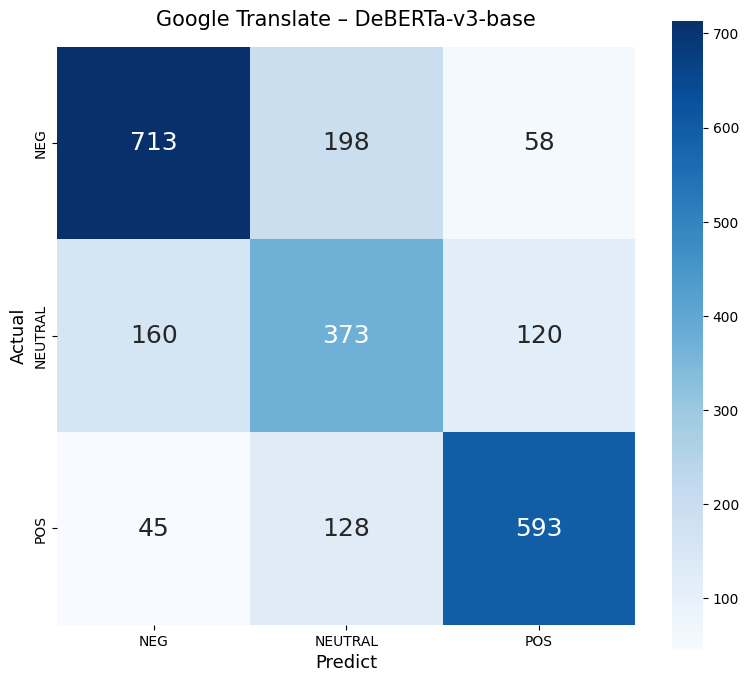


💾 Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_google_deberta.png

📦 Ham Confusion Matrix:
         NEG  NEUTRAL  POS
NEG      713      198   58
NEUTRAL  160      373  120
POS       45      128  593


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

save_dir = "/content/drive/MyDrive/NLP/Translation/figures"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "cm_google_deberta.png")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm_db,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    cbar=True,
    square=True,
    annot_kws={"size": 18},
    ax=ax,
)
ax.set_xlabel("Predict", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
ax.set_title("Google Translate – DeBERTa-v3-base", fontsize=15, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n💾 Kaydedildi: {save_path}")
print("\n📦 Ham Confusion Matrix:")
print(pd.DataFrame(cm_db, index=label_names, columns=label_names))

In [13]:
test_df_reset_db = test_df.reset_index(drop=True).copy()
test_df_reset_db["pred"] = y_pred_db
test_df_reset_db["true"] = y_true_db

lang_results_db = {}
for lang in languages:
    sub = test_df_reset_db[test_df_reset_db["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values

    cm_lang = confusion_matrix(yt, yp, labels=[0, 1, 2])
    spec_lang = np.mean(per_class_specificity(cm_lang))

    lang_results_db[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_lang,
    }

lang_report_db = pd.DataFrame(lang_results_db).round(4)
print("📊 Dil Bazlı Classification Report — DeBERTa (Google Translate)\n")
print(lang_report_db.to_string())

📊 Dil Bazlı Classification Report — DeBERTa (Google Translate)

             Arabic  Chinese  French  Italian
Accuracy     0.6924   0.7067  0.7900   0.6223
Precision    0.6968   0.7171  0.7896   0.6249
Recall       0.6924   0.7067  0.7900   0.6223
F1-Score     0.6942   0.7114  0.7897   0.6222
Specificity  0.8380   0.8563  0.8963   0.8008


In [15]:
import pandas as pd

deberta_row = pd.DataFrame({
    "Model": ["DeBERTa"],
    "Fold 1": [cv_results_deberta[0]["eval_f1_weighted"]],
    "Fold 2": [cv_results_deberta[1]["eval_f1_weighted"]],
    "Fold 3": [cv_results_deberta[2]["eval_f1_weighted"]],
    "Fold 4": [cv_results_deberta[3]["eval_f1_weighted"]],
    "Fold 5": [cv_results_deberta[4]["eval_f1_weighted"]],
})

deberta_row["Average"] = deberta_row[["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]].mean(axis=1)

print(deberta_row.round(4).to_string(index=False))

  Model  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Average
DeBERTa  0.7136  0.6961  0.6991  0.6917  0.6962   0.6993


In [16]:
save_root = "/content/drive/MyDrive/NLP/Translation/final_models_v2"
os.makedirs(save_root, exist_ok=True)

deberta_path = os.path.join(save_root, "deberta_google_final")
final_trainer_db.save_model(deberta_path)

print(f"✅ DeBERTa kaydedildi: {deberta_path}")

✅ DeBERTa kaydedildi: /content/drive/MyDrive/NLP/Translation/final_models_v2/deberta_google_final


In [3]:
import transformers
print("transformers:", transformers.__version__)

transformers: 4.46.3


In [5]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)

SEED = 42
np.random.seed(SEED)

train_df = pd.read_csv("/content/drive/MyDrive/NLP/Translation/merged_datasets/holdout_train_google.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/NLP/Translation/merged_datasets/holdout_test_google.csv")

train_df["translated_text"] = train_df["translated_text"].astype(str)
test_df["translated_text"]  = test_df["translated_text"].astype(str)

label_map = {"NEG": 0, "NEUTRAL": 1, "POS": 2}
label_names = ["NEG", "NEUTRAL", "POS"]
train_df["label"] = train_df["sentiment"].map(label_map).astype(int)
test_df["label"]  = test_df["sentiment"].map(label_map).astype(int)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def macro_specificity(y_true, y_pred, num_labels=3):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_labels)))
    specs = []
    total = cm.sum()
    for i in range(num_labels):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        specs.append(spec)
    return float(np.mean(specs))

def per_class_specificity(cm):
    total = cm.sum()
    specs = []
    for i in range(len(cm)):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN
        specs.append(TN / (TN + FP) if (TN + FP) > 0 else 0.0)
    return specs

languages = ["ar", "zh", "fr", "it"]
lang_names = {"ar": "Arabic", "zh": "Chinese", "fr": "French", "it": "Italian"}

print(f"✅ Train: {train_df.shape}, Test: {test_df.shape}")
print(f"💻 Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

✅ Train: (9549, 5), Test: (2388, 5)
💻 Device: cuda


In [7]:
import os

for name in ["roberta_google_final", "bertweet_google_final", "deberta_google_final"]:
    path = f"/content/drive/MyDrive/NLP/Translation/final_models_v2/{name}"
    print(f"\n📂 {name}:")
    if os.path.exists(path):
        for f in sorted(os.listdir(path)):
            print(f"   {f}")
    else:
        print("   ❌ Klasör yok")


📂 roberta_google_final:
   config.json
   model.safetensors
   training_args.bin

📂 bertweet_google_final:
   config.json
   model.safetensors
   training_args.bin

📂 deberta_google_final:
   added_tokens.json
   config.json
   model.safetensors
   special_tokens_map.json
   spm.model
   tokenizer.json
   tokenizer_config.json
   training_args.bin


In [8]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch, gc
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Model yolları + her birinin kaynak tokenizer'ı
model_config_google = {
    "roberta": {
        "model_path": "/content/drive/MyDrive/NLP/Translation/final_models_v2/roberta_google_final",
        "tokenizer_name": "cardiffnlp/twitter-roberta-base-sentiment",
        "tokenizer_kwargs": {},
    },
    "bertweet": {
        "model_path": "/content/drive/MyDrive/NLP/Translation/final_models_v2/bertweet_google_final",
        "tokenizer_name": "vinai/bertweet-base",
        "tokenizer_kwargs": {"normalization": True},
    },
    "deberta": {
        "model_path": "/content/drive/MyDrive/NLP/Translation/final_models_v2/deberta_google_final",
        "tokenizer_name": "/content/drive/MyDrive/NLP/Translation/final_models_v2/deberta_google_final",
        "tokenizer_kwargs": {},
    },
}

def get_probs(model_path, tokenizer_name, tokenizer_kwargs, texts, max_length=128, batch_size=32):
    tok = AutoTokenizer.from_pretrained(tokenizer_name, **tokenizer_kwargs)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_path).to(device).eval()

    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tok(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = mdl(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

    del mdl, tok
    gc.collect()
    torch.cuda.empty_cache()
    return np.concatenate(all_probs, axis=0)

texts = test_df["translated_text"].tolist()
y_true_ens = test_df["label"].values

probs_google = {}
for name, cfg in model_config_google.items():
    print(f"🔹 {name} softmax olasılıkları alınıyor...")
    probs_google[name] = get_probs(
        cfg["model_path"],
        cfg["tokenizer_name"],
        cfg["tokenizer_kwargs"],
        texts,
    )
    print(f"   ✅ shape: {probs_google[name].shape}")

print(f"\n✅ Üç modelden de olasılıklar toplandı.")

🔹 roberta softmax olasılıkları alınıyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


   ✅ shape: (2388, 3)
🔹 deberta softmax olasılıkları alınıyor...
   ✅ shape: (2388, 3)

✅ Üç modelden de olasılıklar toplandı.


In [9]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from collections import Counter
import pandas as pd
import numpy as np

cv_f1_scores = {
    "roberta":  0.7057,
    "bertweet": 0.7064,
    "deberta":  0.6993,
}

preds_hard = np.stack([
    probs_google["roberta"].argmax(axis=1),
    probs_google["bertweet"].argmax(axis=1),
    probs_google["deberta"].argmax(axis=1),
], axis=1)
y_pred_majority = np.array([Counter(row).most_common(1)[0][0] for row in preds_hard])

avg_probs = (probs_google["roberta"] + probs_google["bertweet"] + probs_google["deberta"]) / 3
y_pred_soft = avg_probs.argmax(axis=1)

w = np.array([cv_f1_scores["roberta"], cv_f1_scores["bertweet"], cv_f1_scores["deberta"]])
w = w / w.sum()
print(f"Ağırlıklar: RoBERTa={w[0]:.4f}, BERTweet={w[1]:.4f}, DeBERTa={w[2]:.4f}")

weighted_probs = (
    w[0] * probs_google["roberta"] +
    w[1] * probs_google["bertweet"] +
    w[2] * probs_google["deberta"]
)
y_pred_weighted = weighted_probs.argmax(axis=1)

def eval_preds(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return {
        "Accuracy":    accuracy_score(y_true, y_pred),
        "Precision":   precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall":      recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-Score":    f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Specificity": np.mean(per_class_specificity(cm)),
    }

results_ens = {
    "Majority Voting": eval_preds(y_true_ens, y_pred_majority),
    "Soft Voting":     eval_preds(y_true_ens, y_pred_soft),
    "Weighted Voting": eval_preds(y_true_ens, y_pred_weighted),
}

ens_df = pd.DataFrame(results_ens).T
print("\n📊 Google Translate — Ensemble Karşılaştırması\n")
print(ens_df.round(4).to_string())

Ağırlıklar: RoBERTa=0.3342, BERTweet=0.3346, DeBERTa=0.3312

📊 Google Translate — Ensemble Karşılaştırması

                 Accuracy  Precision  Recall  F1-Score  Specificity
Majority Voting    0.7119     0.7095  0.7119    0.7105       0.8559
Soft Voting        0.7165     0.7140  0.7165    0.7150       0.8581
Weighted Voting    0.7161     0.7135  0.7161    0.7145       0.8579


In [10]:
cm_maj = confusion_matrix(y_true_ens, y_pred_majority)

per_class_maj = pd.DataFrame({
    "Accuracy":    [np.nan]*3,
    "Precision":   precision_score(y_true_ens, y_pred_majority, average=None, zero_division=0),
    "Recall":      recall_score(y_true_ens, y_pred_majority, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true_ens, y_pred_majority, average=None, zero_division=0),
    "Specificity": per_class_specificity(cm_maj),
}, index=label_names)

overall_maj = pd.Series({
    "Accuracy":    accuracy_score(y_true_ens, y_pred_majority),
    "Precision":   precision_score(y_true_ens, y_pred_majority, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true_ens, y_pred_majority, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true_ens, y_pred_majority, average="weighted", zero_division=0),
    "Specificity": np.mean(per_class_specificity(cm_maj)),
}, name="Overall (weighted)")

report_maj = pd.concat([per_class_maj, overall_maj.to_frame().T])
print("📊 Classification Report — Majority Voting Ensemble (Google)\n")
print(report_maj.round(4).to_string())

📊 Classification Report — Majority Voting Ensemble (Google)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.7727  0.7647    0.7687       0.8464
NEUTRAL                  NaN     0.5618  0.5360    0.5486       0.8427
POS                      NaN     0.7556  0.7950    0.7748       0.8785
Overall (weighted)    0.7119     0.7095  0.7119    0.7105       0.8559


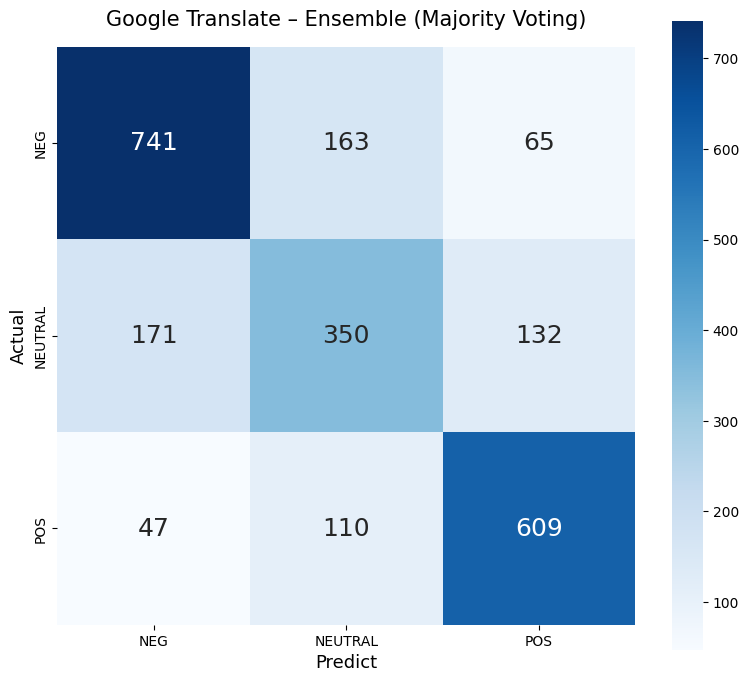


💾 Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_google_ensemble_majority.png

📦 Ham Confusion Matrix:
         NEG  NEUTRAL  POS
NEG      741      163   65
NEUTRAL  171      350  132
POS       47      110  609


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

save_dir = "/content/drive/MyDrive/NLP/Translation/figures"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "cm_google_ensemble_majority.png")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm_maj,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    cbar=True,
    square=True,
    annot_kws={"size": 18},
    ax=ax,
)
ax.set_xlabel("Predict", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
ax.set_title("Google Translate – Ensemble (Majority Voting)", fontsize=15, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n💾 Kaydedildi: {save_path}")
print("\n📦 Ham Confusion Matrix:")
print(pd.DataFrame(cm_maj, index=label_names, columns=label_names))

In [12]:
test_df_reset_maj = test_df.reset_index(drop=True).copy()
test_df_reset_maj["pred"] = y_pred_majority
test_df_reset_maj["true"] = y_true_ens

lang_results_maj = {}
for lang in languages:
    sub = test_df_reset_maj[test_df_reset_maj["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values

    cm_lang = confusion_matrix(yt, yp, labels=[0, 1, 2])
    spec_lang = np.mean(per_class_specificity(cm_lang))

    lang_results_maj[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_lang,
    }

lang_report_maj = pd.DataFrame(lang_results_maj).round(4)
print("📊 Dil Bazlı Classification Report — Majority Voting Ensemble (Google)\n")
print(lang_report_maj.to_string())

📊 Dil Bazlı Classification Report — Majority Voting Ensemble (Google)

             Arabic  Chinese  French  Italian
Accuracy     0.6824   0.7217  0.8050   0.6374
Precision    0.6812   0.7153  0.8017   0.6402
Recall       0.6824   0.7217  0.8050   0.6374
F1-Score     0.6813   0.7179  0.8030   0.6379
Specificity  0.8320   0.8596  0.9031   0.8117
